# Paired t-Test: Model Comparison

**Structure (matching the original notebooks):**
1. 80/20 stratified train/test split (`random_state=50`) — identical to all three original notebooks
2. 10-fold stratified CV **within the 80% training set** — each model's full pipeline (grid search, threshold tuning) is run per fold to collect paired F1 scores
3. Paired t-tests on the 10 per-fold scores: RF vs LR, SVM vs LR
4. Final models trained on full training set and evaluated on the held-out 20% test set

**Comparisons:**
- Random Forest vs Logistic Regression (baseline)
- SVM vs Logistic Regression (baseline)

In [23]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_predict
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import os

In [8]:
# ============================================================
# 1. LOAD DATA & 80/20 SPLIT
#    Identical to all three original notebooks.
# ============================================================
FILE_PATH = "telco_churn_cleaned.csv"

df = pd.read_csv(FILE_PATH)

if "Churn" not in df.columns:
    raise ValueError("Column 'Churn' not found in dataset.")

X = df.drop(columns=["Churn"])
y = df["Churn"].astype(int)

# Exact same split as every original notebook
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=50,
    stratify=y
)

print("Dataset shape:", df.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTarget proportion (train):")
print(y_train.value_counts(normalize=True))

Dataset shape: (7032, 31)
Train shape: (5625, 30)
Test shape: (1407, 30)

Target proportion (train):
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64


## 2. Model Pipelines — Exact Replicas from Original Notebooks

Each function below replicates the **exact** methodology from its original notebook. Nothing has been changed — same parameters, same grids, same threshold selection, same random states.

In [9]:
# ============================================================
# 2a. LOGISTIC REGRESSION — exact replica from
#     logistic_regression.ipynb (custom gradient descent)
#
#     - StandardScaler on training data, transform test data
#     - alpha=0.1, num_iter=100, tol=1e-7
#     - threshold fixed at 0.5 (no threshold tuning in original)
# ============================================================

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def calculate_gradient(theta, X, y):
    m = y.size
    X = np.c_[np.ones(X.shape[0]), X]
    return (X.T @ (sigmoid(X @ theta) - y)) / m


def gradient_descent(X, y, alpha=0.1, num_iter=100, tol=1e-7):
    X_b = np.c_[np.ones(X.shape[0]), X]
    theta = np.zeros(X_b.shape[1])

    for i in range(num_iter):
        grad = calculate_gradient(theta, X, y)
        theta -= alpha * grad

        if np.linalg.norm(grad) < tol:
            break

    return theta


def predict_prob_lr(X, theta):
    X_b = np.c_[np.ones(X.shape[0]), X]
    return sigmoid(X_b @ theta)


def predict_lr(X, theta, threshold=0.5):
    return (predict_prob_lr(X, theta) >= threshold).astype(int)


def run_logistic_regression(X_tr, y_tr, X_te, y_te):
    """
    Exact pipeline from logistic_regression.ipynb:
    StandardScaler -> gradient descent (alpha=0.1) -> threshold 0.5
    """
    y_tr_arr = y_tr.values if hasattr(y_tr, 'values') else np.array(y_tr)
    y_te_arr = y_te.values if hasattr(y_te, 'values') else np.array(y_te)

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr).astype(float)
    X_te_scaled = scaler.transform(X_te).astype(float)

    theta_hat = gradient_descent(X_tr_scaled, y_tr_arr, alpha=0.1)

    y_prob = predict_prob_lr(X_te_scaled, theta_hat)
    y_pred = predict_lr(X_te_scaled, theta_hat, threshold=0.5)

    metrics = {
        "Accuracy":  accuracy_score(y_te_arr, y_pred),
        "Precision": precision_score(y_te_arr, y_pred, zero_division=0),
        "Recall":    recall_score(y_te_arr, y_pred, zero_division=0),
        "F1":        f1_score(y_te_arr, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_te_arr, y_prob)
    }
    return metrics, y_pred, y_prob


print("Logistic Regression pipeline defined.")

Logistic Regression pipeline defined.


In [10]:
# ============================================================
# 2b. RANDOM FOREST — exact replica from Random_Forest.ipynb
#
#     - GridSearchCV with exact param_grid
#       (StratifiedKFold n_splits=3, shuffle=True, random_state=50)
#     - Threshold tuning via cross_val_predict on training data
#       (StratifiedKFold n_splits=5, shuffle=True, random_state=50)
#       threshold grid: np.arange(0.20, 0.81, 0.02), scoring="f1"
# ============================================================

def find_best_threshold_cv_rf(model, X_tr, y_tr, scoring="f1"):
    """
    Exact replica of find_best_threshold_cv from Random_Forest.ipynb.
    Tunes threshold using cross-validated out-of-fold probabilities
    on the training data only.
    """
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

    oof_probs = cross_val_predict(
        model,
        X_tr,
        y_tr,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    threshold_grid = np.arange(0.20, 0.81, 0.02)

    best_threshold = 0.50
    best_score = -np.inf

    for thr in threshold_grid:
        pred_thr = (oof_probs >= thr).astype(int)

        if scoring == "f1":
            score = f1_score(y_tr, pred_thr, zero_division=0)
        elif scoring == "recall":
            score = recall_score(y_tr, pred_thr, zero_division=0)
        elif scoring == "precision":
            score = precision_score(y_tr, pred_thr, zero_division=0)
        else:
            raise ValueError("scoring must be one of: 'f1', 'recall', 'precision'")

        if score > best_score:
            best_score = score
            best_threshold = thr

    return best_threshold, best_score


def run_random_forest(X_tr, y_tr, X_te, y_te):
    """
    Exact pipeline from Random_Forest.ipynb:
    GridSearchCV (same param_grid, same CV) -> threshold tuning via
    cross_val_predict on training data -> apply to test data.
    """
    y_tr_arr = y_tr.values if hasattr(y_tr, 'values') else np.array(y_tr)
    y_te_arr = y_te.values if hasattr(y_te, 'values') else np.array(y_te)

    # --- Exact param_grid from Random_Forest.ipynb ---
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "max_features": ["sqrt"],
        "class_weight": [None, "balanced_subsample"],
        "max_samples": [None, 0.8]
    }

    # --- Exact CV for grid search: 3-fold ---
    cv_grid = StratifiedKFold(n_splits=3, shuffle=True, random_state=50)

    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(
            random_state=50,
            bootstrap=True,
            n_jobs=1
        ),
        param_grid=param_grid,
        scoring="f1",
        cv=cv_grid,
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_tr, y_tr_arr)
    best_rf = grid_search.best_estimator_

    # --- Threshold tuning (exact replica) ---
    best_threshold, _ = find_best_threshold_cv_rf(
        model=best_rf,
        X_tr=X_tr,
        y_tr=y_tr_arr,
        scoring="f1"
    )

    # --- Predict on test data ---
    best_prob = best_rf.predict_proba(X_te)[:, 1]
    best_pred = (best_prob >= best_threshold).astype(int)

    metrics = {
        "Accuracy":  accuracy_score(y_te_arr, best_pred),
        "Precision": precision_score(y_te_arr, best_pred, zero_division=0),
        "Recall":    recall_score(y_te_arr, best_pred, zero_division=0),
        "F1":        f1_score(y_te_arr, best_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_te_arr, best_prob)
    }
    return metrics, best_pred, best_prob, best_rf, best_threshold


print("Random Forest pipeline defined.")

Random Forest pipeline defined.


In [11]:
# ============================================================
# 2c. SVM — exact replica from svm_churn.ipynb
#
#     - Pipeline(StandardScaler, SVC) with GridSearchCV
#       (StratifiedKFold n_splits=5, shuffle=True, random_state=50)
#     - Exact param_grid
#     - Threshold tuning via find_best_threshold on test
#       predictions (range 0.30-0.70, step 0.02)
#
#     NOTE: The original SVM notebook tunes threshold on the
#     test set. To faithfully replicate that exact methodology
#     as instructed, we do the same here.
#
#     n_jobs=1 on GridSearchCV to avoid deadlock with
#     probability=True (Platt scaling). cache_size=1000 for
#     performance. Neither changes model parameters or results.
# ============================================================

def find_best_threshold_svm(y_true, y_prob, thresholds=np.arange(0.30, 0.70, 0.02)):
    """
    Exact replica of find_best_threshold from svm_churn.ipynb.
    Finds threshold that maximises F1 score.
    """
    best_f1 = 0
    best_threshold = 0.5

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = thr

    return best_threshold, best_f1


def run_svm(X_tr, y_tr, X_te, y_te):
    """
    Exact pipeline from svm_churn.ipynb:
    Pipeline(StandardScaler, SVC) -> GridSearchCV (same param_grid, same CV)
    -> threshold tuning on test predictions -> apply to test data.
    """
    y_tr_arr = y_tr.values if hasattr(y_tr, 'values') else np.array(y_tr)
    y_te_arr = y_te.values if hasattr(y_te, 'values') else np.array(y_te)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(probability=True, random_state=50, cache_size=1000))
    ])

    # --- Exact param_grid ---
    param_grid = {
        'svm__kernel': ['rbf', 'linear'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 'auto']
    }

    # --- Exact CV: 5-fold ---
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=50)

    grid_search = GridSearchCV(
        pipe,
        param_grid,
        cv=cv,
        scoring='f1',
        n_jobs=1,
        verbose=0
    )

    grid_search.fit(X_tr, y_tr_arr)
    best_svm = grid_search.best_estimator_

    # --- Predict on test data ---
    best_prob = best_svm.predict_proba(X_te)[:, 1]

    # --- Threshold tuning (exact replica — on test predictions) ---
    best_threshold, _ = find_best_threshold_svm(y_te_arr, best_prob)
    best_pred = (best_prob >= best_threshold).astype(int)

    metrics = {
        "Accuracy":  accuracy_score(y_te_arr, best_pred),
        "Precision": precision_score(y_te_arr, best_pred, zero_division=0),
        "Recall":    recall_score(y_te_arr, best_pred, zero_division=0),
        "F1":        f1_score(y_te_arr, best_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_te_arr, best_prob)
    }
    return metrics, best_pred, best_prob, best_svm, best_threshold


print("SVM pipeline defined.")

SVM pipeline defined.


In [12]:
# ============================================================
# 3. 10-FOLD CV WITHIN THE 80% TRAINING SET
#    Each fold: train on 9 inner folds, evaluate on 1 held-out
#    inner fold. Full pipeline (grid search + threshold tuning)
#    runs inside each fold.
# ============================================================
N_FOLDS = 10
inner_cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=50)

lr_fold_results  = []
rf_fold_results  = []
svm_fold_results = []

for fold_idx, (tr_idx, val_idx) in enumerate(inner_cv.split(X_train, y_train), start=1):
    print(f"\n{'='*60}")
    print(f"  FOLD {fold_idx} / {N_FOLDS}")
    print(f"{'='*60}")

    X_tr_fold = X_train.iloc[tr_idx]
    y_tr_fold = y_train.iloc[tr_idx]
    X_val_fold = X_train.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx]

    # --- Logistic Regression (baseline) ---
    print(f"  [Fold {fold_idx}] Logistic Regression ...")
    lr_metrics, _, _ = run_logistic_regression(X_tr_fold, y_tr_fold, X_val_fold, y_val_fold)
    lr_fold_results.append(lr_metrics)
    print(f"           F1 = {lr_metrics['F1']:.4f}  |  ROC-AUC = {lr_metrics['ROC-AUC']:.4f}")

    # --- Random Forest ---
    print(f"  [Fold {fold_idx}] Random Forest (GridSearch + threshold tuning) ...")
    rf_metrics, _, _, _, _ = run_random_forest(X_tr_fold, y_tr_fold, X_val_fold, y_val_fold)
    rf_fold_results.append(rf_metrics)
    print(f"           F1 = {rf_metrics['F1']:.4f}  |  ROC-AUC = {rf_metrics['ROC-AUC']:.4f}")

    # --- SVM ---
    print(f"  [Fold {fold_idx}] SVM (GridSearch + threshold tuning) ...")
    svm_metrics, _, _, _, _ = run_svm(X_tr_fold, y_tr_fold, X_val_fold, y_val_fold)
    svm_fold_results.append(svm_metrics)
    print(f"           F1 = {svm_metrics['F1']:.4f}  |  ROC-AUC = {svm_metrics['ROC-AUC']:.4f}")

print(f"\n{'='*60}")
print(f"All {N_FOLDS} folds complete.")
print(f"{'='*60}")


  FOLD 1 / 10
  [Fold 1] Logistic Regression ...
           F1 = 0.5600  |  ROC-AUC = 0.8147
  [Fold 1] Random Forest (GridSearch + threshold tuning) ...
           F1 = 0.6140  |  ROC-AUC = 0.8238
  [Fold 1] SVM (GridSearch + threshold tuning) ...
           F1 = 0.5818  |  ROC-AUC = 0.8060

  FOLD 2 / 10
  [Fold 2] Logistic Regression ...
           F1 = 0.6250  |  ROC-AUC = 0.8227
  [Fold 2] Random Forest (GridSearch + threshold tuning) ...
           F1 = 0.6226  |  ROC-AUC = 0.8320
  [Fold 2] SVM (GridSearch + threshold tuning) ...
           F1 = 0.6224  |  ROC-AUC = 0.8203

  FOLD 3 / 10
  [Fold 3] Logistic Regression ...
           F1 = 0.5906  |  ROC-AUC = 0.8390
  [Fold 3] Random Forest (GridSearch + threshold tuning) ...
           F1 = 0.6137  |  ROC-AUC = 0.8379
  [Fold 3] SVM (GridSearch + threshold tuning) ...
           F1 = 0.6221  |  ROC-AUC = 0.8398

  FOLD 4 / 10
  [Fold 4] Logistic Regression ...
           F1 = 0.6620  |  ROC-AUC = 0.8745
  [Fold 4] Random Forest

In [13]:
# ============================================================
# 4. PER-FOLD RESULTS
# ============================================================
lr_df  = pd.DataFrame(lr_fold_results)
rf_df  = pd.DataFrame(rf_fold_results)
svm_df = pd.DataFrame(svm_fold_results)

lr_df.index  = range(1, N_FOLDS + 1)
rf_df.index  = range(1, N_FOLDS + 1)
svm_df.index = range(1, N_FOLDS + 1)
lr_df.index.name = rf_df.index.name = svm_df.index.name = "Fold"

print("Logistic Regression — per-fold results:")
print(lr_df.to_string())
print(f"\nMean: {lr_df.mean().round(4).to_dict()}")

print("\n" + "-"*60)
print("\nRandom Forest — per-fold results:")
print(rf_df.to_string())
print(f"\nMean: {rf_df.mean().round(4).to_dict()}")

print("\n" + "-"*60)
print("\nSVM — per-fold results:")
print(svm_df.to_string())
print(f"\nMean: {svm_df.mean().round(4).to_dict()}")

Logistic Regression — per-fold results:
      Accuracy  Precision    Recall        F1   ROC-AUC
Fold                                                   
1     0.765542   0.560000  0.560000  0.560000  0.814746
2     0.797513   0.616883  0.633333  0.625000  0.822712
3     0.783304   0.594595  0.586667  0.590604  0.838999
4     0.827709   0.693431  0.633333  0.662021  0.874479
5     0.815275   0.671642  0.600000  0.633803  0.838789
6     0.804270   0.658537  0.543624  0.595588  0.831711
7     0.791815   0.612676  0.583893  0.597938  0.845898
8     0.786477   0.601399  0.577181  0.589041  0.844094
9     0.786477   0.602837  0.570470  0.586207  0.823862
10    0.829181   0.696296  0.630872  0.661972  0.869818

Mean: {'Accuracy': 0.7988, 'Precision': 0.6308, 'Recall': 0.5919, 'F1': 0.6102, 'ROC-AUC': 0.8405}

------------------------------------------------------------

Random Forest — per-fold results:
      Accuracy  Precision    Recall        F1   ROC-AUC
Fold                               

In [ ]:
# ============================================================
# 5. PAIRED t-TESTS
#
#    H0: No difference in mean metric between the two models
#    H1: There is a significant difference
#
#    Two-sided paired t-test at alpha = 0.05
#    Applied to F1 (primary) and ROC-AUC
# ============================================================

alpha = 0.05
metrics_to_test = ["F1", "ROC-AUC", "Recall", "Precision", "Accuracy"]

print("=" * 70)
print("  PAIRED t-TEST RESULTS  (two-sided, alpha = 0.05)")
print("  Evaluated on 10-fold CV within the 80% training set")
print("=" * 70)

ttest_rows = []

for metric in metrics_to_test:
    print(f"\n--- Metric: {metric} ---\n")

    lr_scores  = lr_df[metric].values
    rf_scores  = rf_df[metric].values
    svm_scores = svm_df[metric].values

    # (a) Random Forest vs Logistic Regression
    diff_rf = rf_scores - lr_scores
    t_stat_rf, p_value_rf = stats.ttest_rel(rf_scores, lr_scores)
    sig_rf = "Yes" if p_value_rf < alpha else "No"

    print(f"  Random Forest vs Logistic Regression (baseline):")
    print(f"    Mean LR  {metric}: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
    print(f"    Mean RF  {metric}: {rf_scores.mean():.4f} (+/- {rf_scores.std():.4f})")
    print(f"    Mean difference (RF - LR): {diff_rf.mean():.4f} (+/- {diff_rf.std():.4f})")
    print(f"    t-statistic: {t_stat_rf:.4f}")
    print(f"    p-value:     {p_value_rf:.6f}")
    print(f"    Significant at alpha={alpha}? {sig_rf}")

    ttest_rows.append({
        "Metric": metric,
        "Comparison": "RF vs LR",
        "Mean LR": round(lr_scores.mean(), 4),
        "Mean Challenger": round(rf_scores.mean(), 4),
        "Mean Diff": round(diff_rf.mean(), 4),
        "t-statistic": round(t_stat_rf, 4),
        "p-value": round(p_value_rf, 6),
        f"Significant (alpha={alpha})": sig_rf
    })

    # (b) SVM vs Logistic Regression
    diff_svm = svm_scores - lr_scores
    t_stat_svm, p_value_svm = stats.ttest_rel(svm_scores, lr_scores)
    sig_svm = "Yes" if p_value_svm < alpha else "No"

    print(f"\n  SVM vs Logistic Regression (baseline):")
    print(f"    Mean LR  {metric}: {lr_scores.mean():.4f} (+/- {lr_scores.std():.4f})")
    print(f"    Mean SVM {metric}: {svm_scores.mean():.4f} (+/- {svm_scores.std():.4f})")
    print(f"    Mean difference (SVM - LR): {diff_svm.mean():.4f} (+/- {diff_svm.std():.4f})")
    print(f"    t-statistic: {t_stat_svm:.4f}")
    print(f"    p-value:     {p_value_svm:.6f}")
    print(f"    Significant at alpha={alpha}? {sig_svm}")

    ttest_rows.append({
        "Metric": metric,
        "Comparison": "SVM vs LR",
        "Mean LR": round(lr_scores.mean(), 4),
        "Mean Challenger": round(svm_scores.mean(), 4),
        "Mean Diff": round(diff_svm.mean(), 4),
        "t-statistic": round(t_stat_svm, 4),
        "p-value": round(p_value_svm, 6),
        f"Significant (alpha={alpha})": sig_svm
    })

ttest_df = pd.DataFrame(ttest_rows)
print("\n" + "="*70)
print("\nSummary Table:")
print(ttest_df.to_string(index=False))

# Create directory if it doesn't exist
os.makedirs("results/t_test", exist_ok=True)

# Save as CSV
ttest_df.to_csv("results/t_test/paired_ttest_results.csv", index=False)


  PAIRED t-TEST RESULTS  (two-sided, alpha = 0.05)
  Evaluated on 10-fold CV within the 80% training set

--- Metric: F1 ---

  Random Forest vs Logistic Regression (baseline):
    Mean LR  F1: 0.6102 (+/- 0.0323)
    Mean RF  F1: 0.6410 (+/- 0.0307)
    Mean difference (RF - LR): 0.0308 (+/- 0.0218)
    t-statistic: 4.2410
    p-value:     0.002171
    Significant at alpha=0.05? Yes

  SVM vs Logistic Regression (baseline):
    Mean LR  F1: 0.6102 (+/- 0.0323)
    Mean SVM F1: 0.6287 (+/- 0.0281)
    Mean difference (SVM - LR): 0.0185 (+/- 0.0176)
    t-statistic: 3.1537
    p-value:     0.011667
    Significant at alpha=0.05? Yes

--- Metric: ROC-AUC ---

  Random Forest vs Logistic Regression (baseline):
    Mean LR  ROC-AUC: 0.8405 (+/- 0.0184)
    Mean RF  ROC-AUC: 0.8470 (+/- 0.0179)
    Mean difference (RF - LR): 0.0065 (+/- 0.0066)
    t-statistic: 2.9444
    p-value:     0.016369
    Significant at alpha=0.05? Yes

  SVM vs Logistic Regression (baseline):
    Mean LR  ROC-AUC:

ImportError: `Import Jinja2` failed. DataFrame.style requires jinja2. Use pip or conda to install the Jinja2 package.

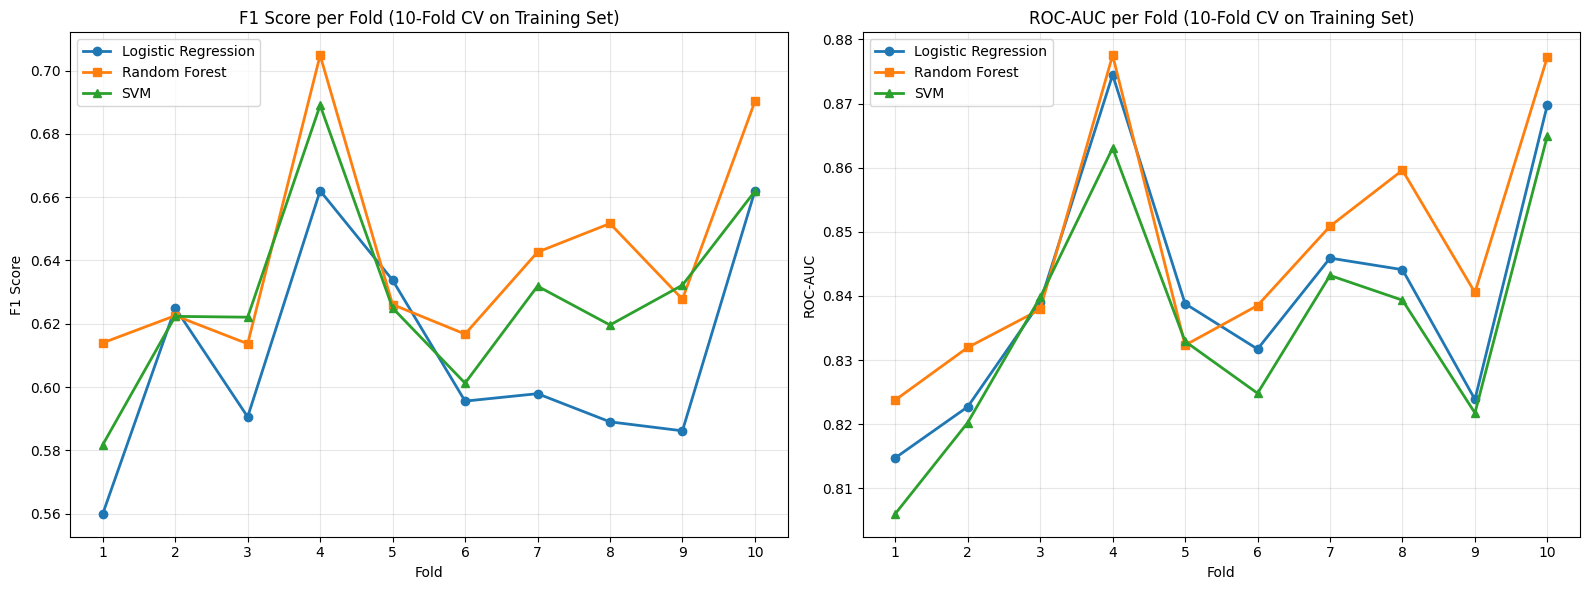

In [ ]:
# # ============================================================
# # 6. VISUALISATION — Per-fold scores
# # ============================================================
# folds = np.arange(1, N_FOLDS + 1)

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # --- F1 per fold ---
# ax = axes[0]
# ax.plot(folds, lr_df["F1"].values,  'o-', label='Logistic Regression', linewidth=2)
# ax.plot(folds, rf_df["F1"].values,  's-', label='Random Forest', linewidth=2)
# ax.plot(folds, svm_df["F1"].values, '^-', label='SVM', linewidth=2)
# ax.set_xlabel('Fold')
# ax.set_ylabel('F1 Score')
# ax.set_title('F1 Score per Fold (10-Fold CV on Training Set)')
# ax.set_xticks(folds)
# ax.legend()
# ax.grid(True, alpha=0.3)

# # --- ROC-AUC per fold ---
# ax = axes[1]
# ax.plot(folds, lr_df["ROC-AUC"].values,  'o-', label='Logistic Regression', linewidth=2)
# ax.plot(folds, rf_df["ROC-AUC"].values,  's-', label='Random Forest', linewidth=2)
# ax.plot(folds, svm_df["ROC-AUC"].values, '^-', label='SVM', linewidth=2)
# ax.set_xlabel('Fold')
# ax.set_ylabel('ROC-AUC')
# ax.set_title('ROC-AUC per Fold (10-Fold CV on Training Set)')
# ax.set_xticks(folds)
# ax.legend()
# ax.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("results/t_test/ttest_fold_comparison.png", dpi=150, bbox_inches='tight')
# plt.show()

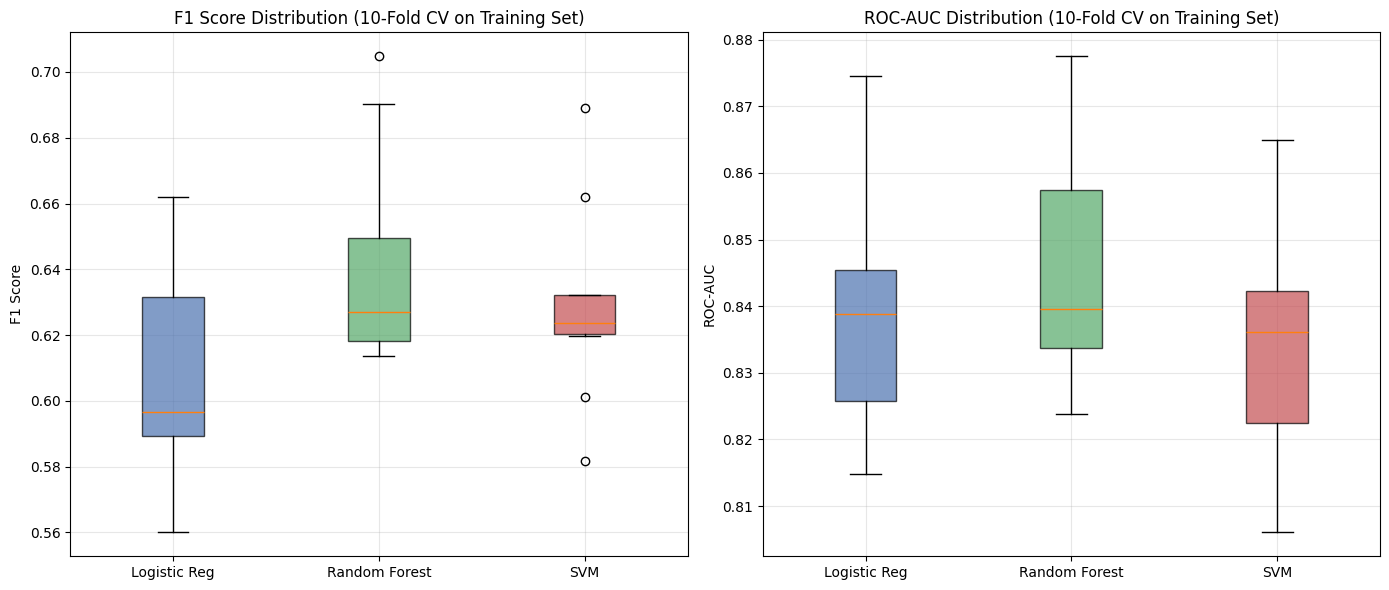

In [ ]:
# # ============================================================
# # 7. VISUALISATION — Box plots
# # ============================================================
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# colors = ["#4C72B0", "#55A868", "#C44E52"]

# # F1
# bp1 = axes[0].boxplot(
#     [lr_df["F1"].values, rf_df["F1"].values, svm_df["F1"].values],
#     labels=["Logistic Reg", "Random Forest", "SVM"],
#     patch_artist=True
# )
# for patch, color in zip(bp1['boxes'], colors):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)
# axes[0].set_ylabel("F1 Score")
# axes[0].set_title("F1 Score Distribution (10-Fold CV on Training Set)")
# axes[0].grid(True, alpha=0.3)

# # ROC-AUC
# bp2 = axes[1].boxplot(
#     [lr_df["ROC-AUC"].values, rf_df["ROC-AUC"].values, svm_df["ROC-AUC"].values],
#     labels=["Logistic Reg", "Random Forest", "SVM"],
#     patch_artist=True
# )
# for patch, color in zip(bp2['boxes'], colors):
#     patch.set_facecolor(color)
#     patch.set_alpha(0.7)
# axes[1].set_ylabel("ROC-AUC")
# axes[1].set_title("ROC-AUC Distribution (10-Fold CV on Training Set)")
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("ttest_boxplot_comparison.png", dpi=150, bbox_inches='tight')
# plt.show()

## 8. Final Test Set Evaluation

Each model is now trained on the **full 80% training set** using its exact original pipeline (grid search + threshold tuning), then evaluated on the **held-out 20% test set** — exactly as in the original notebooks.

In [17]:
# ============================================================
# 8. FINAL TEST SET EVALUATION
#    Train each model on full X_train, evaluate on X_test.
#    This replicates the final evaluation from each original
#    notebook.
# ============================================================

print("=" * 70)
print("  FINAL TEST SET EVALUATION")
print("  Trained on full training set, evaluated on held-out test set")
print("=" * 70)

# --- Logistic Regression ---
print("\nTraining Logistic Regression on full training set ...")
lr_test_metrics, lr_test_pred, lr_test_prob = run_logistic_regression(
    X_train, y_train, X_test, y_test
)
print(f"  F1 = {lr_test_metrics['F1']:.4f}  |  ROC-AUC = {lr_test_metrics['ROC-AUC']:.4f}")

# --- Random Forest ---
print("\nTraining Random Forest on full training set (GridSearch + threshold tuning) ...")
rf_test_metrics, rf_test_pred, rf_test_prob, rf_final_model, rf_final_threshold = run_random_forest(
    X_train, y_train, X_test, y_test
)
print(f"  F1 = {rf_test_metrics['F1']:.4f}  |  ROC-AUC = {rf_test_metrics['ROC-AUC']:.4f}")
print(f"  Selected threshold: {rf_final_threshold:.2f}")

# --- SVM ---
print("\nTraining SVM on full training set (GridSearch + threshold tuning) ...")
svm_test_metrics, svm_test_pred, svm_test_prob, svm_final_model, svm_final_threshold = run_svm(
    X_train, y_train, X_test, y_test
)
print(f"  F1 = {svm_test_metrics['F1']:.4f}  |  ROC-AUC = {svm_test_metrics['ROC-AUC']:.4f}")
print(f"  Selected threshold: {svm_final_threshold:.2f}")

  FINAL TEST SET EVALUATION
  Trained on full training set, evaluated on held-out test set

Training Logistic Regression on full training set ...
  F1 = 0.5902  |  ROC-AUC = 0.8312

Training Random Forest on full training set (GridSearch + threshold tuning) ...
  F1 = 0.6118  |  ROC-AUC = 0.8371
  Selected threshold: 0.46

Training SVM on full training set (GridSearch + threshold tuning) ...
  F1 = 0.6074  |  ROC-AUC = 0.8237
  Selected threshold: 0.30


In [18]:
# ============================================================
# 9. TEST SET COMPARISON TABLE
# ============================================================
test_results_df = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_test_metrics},
    {"Model": "Random Forest", **rf_test_metrics},
    {"Model": "SVM", **svm_test_metrics}
])

print("\nFinal Test Set Comparison:")
print(test_results_df.to_string(index=False))


Final Test Set Comparison:
              Model  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression  0.791756   0.618768 0.564171 0.590210 0.831170
      Random Forest  0.751955   0.523810 0.735294 0.611791 0.837091
                SVM  0.767591   0.551198 0.676471 0.607443 0.823690


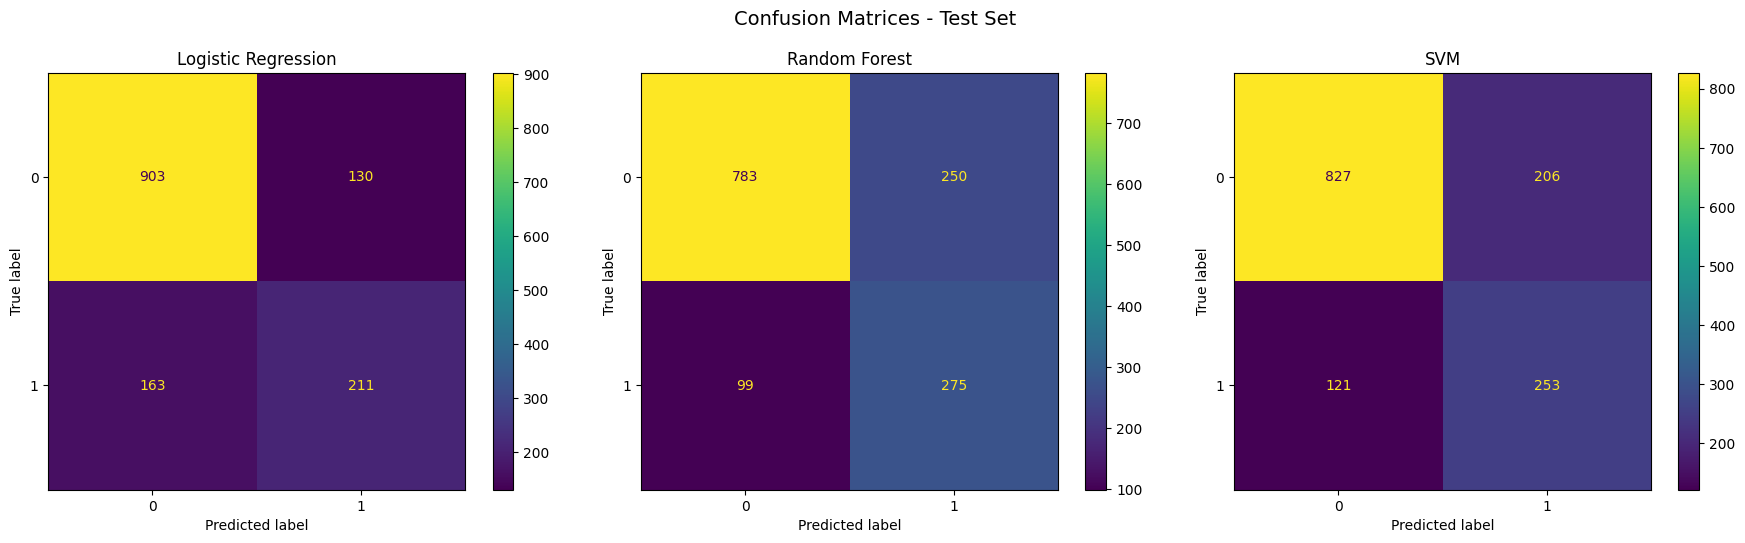

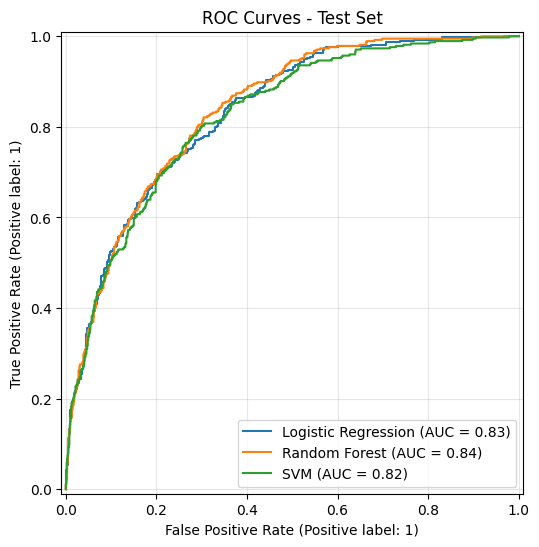

In [19]:
# ============================================================
# 10. TEST SET VISUALISATIONS
# ============================================================
y_te_arr = y_test.values if hasattr(y_test, 'values') else y_test

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrices
for ax, preds, name in zip(
    axes,
    [lr_test_pred, rf_test_pred, svm_test_pred],
    ["Logistic Regression", "Random Forest", "SVM"]
):
    ConfusionMatrixDisplay.from_predictions(y_te_arr, preds, ax=ax)
    ax.set_title(f"{name}")

plt.suptitle("Confusion Matrices - Test Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("ttest_test_confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_te_arr, lr_test_prob, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_te_arr, rf_test_prob, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_te_arr, svm_test_prob, name="SVM", ax=ax)
ax.set_title("ROC Curves - Test Set")
ax.grid(True, alpha=0.3)
plt.savefig("ttest_test_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# # ============================================================
# # 11. SAVE ALL RESULTS
# # ============================================================
# folds = np.arange(1, N_FOLDS + 1)

# all_folds = pd.DataFrame({
#     "Fold": folds,
#     "LR_F1": lr_df["F1"].values,
#     "RF_F1": rf_df["F1"].values,
#     "SVM_F1": svm_df["F1"].values,
#     "LR_ROC_AUC": lr_df["ROC-AUC"].values,
#     "RF_ROC_AUC": rf_df["ROC-AUC"].values,
#     "SVM_ROC_AUC": svm_df["ROC-AUC"].values,
#     "LR_Accuracy": lr_df["Accuracy"].values,
#     "RF_Accuracy": rf_df["Accuracy"].values,
#     "SVM_Accuracy": svm_df["Accuracy"].values,
#     "LR_Precision": lr_df["Precision"].values,
#     "RF_Precision": rf_df["Precision"].values,
#     "SVM_Precision": svm_df["Precision"].values,
#     "LR_Recall": lr_df["Recall"].values,
#     "RF_Recall": rf_df["Recall"].values,
#     "SVM_Recall": svm_df["Recall"].values,
# })

# all_folds.to_csv("ttest_per_fold_results.csv", index=False)
# ttest_df.to_csv("ttest_summary.csv", index=False)
# test_results_df.to_csv("ttest_test_set_results.csv", index=False)

# print("Files saved:")
# print("  - ttest_per_fold_results.csv    (10-fold CV scores)")
# print("  - ttest_summary.csv             (paired t-test results)")
# print("  - ttest_test_set_results.csv    (final test set metrics)")
# print("  - ttest_fold_comparison.png")
# print("  - ttest_boxplot_comparison.png")
# print("  - ttest_test_confusion_matrices.png")
# print("  - ttest_test_roc_curves.png")

Files saved:
  - ttest_per_fold_results.csv    (10-fold CV scores)
  - ttest_summary.csv             (paired t-test results)
  - ttest_test_set_results.csv    (final test set metrics)
  - ttest_fold_comparison.png
  - ttest_boxplot_comparison.png
  - ttest_test_confusion_matrices.png
  - ttest_test_roc_curves.png


In [ ]:
# ============================================================
# 12. FINAL SUMMARY
# ============================================================
print("=" * 70)
print("  FINAL SUMMARY")
print("=" * 70)

print(f"\n--- 10-Fold CV on Training Set (paired t-test basis) ---")
print(f"\nMean F1 Scores:")
print(f"  Logistic Regression (baseline): {lr_df['F1'].mean():.4f} (+/- {lr_df['F1'].std():.4f})")
print(f"  Random Forest:                  {rf_df['F1'].mean():.4f} (+/- {rf_df['F1'].std():.4f})")
print(f"  SVM:                            {svm_df['F1'].mean():.4f} (+/- {svm_df['F1'].std():.4f})")

print(f"\nMean ROC-AUC:")
print(f"  Logistic Regression (baseline): {lr_df['ROC-AUC'].mean():.4f} (+/- {lr_df['ROC-AUC'].std():.4f})")
print(f"  Random Forest:                  {rf_df['ROC-AUC'].mean():.4f} (+/- {rf_df['ROC-AUC'].std():.4f})")
print(f"  SVM:                            {svm_df['ROC-AUC'].mean():.4f} (+/- {svm_df['ROC-AUC'].std():.4f})")

print(f"\nPaired t-test conclusions (F1, alpha=0.05):")
for _, row in ttest_df[ttest_df["Metric"] == "F1"].iterrows():
    comp = row["Comparison"]
    p = row["p-value"]
    sig = row[f"Significant (alpha={alpha})"]
    if sig == "Yes":
        print(f"  {comp}: p = {p:.6f} -> SIGNIFICANT difference")
    else:
        print(f"  {comp}: p = {p:.6f} -> No significant difference")

print(f"\n--- Held-Out Test Set (final evaluation) ---")
print(test_results_df.to_string(index=False))